<a href="https://colab.research.google.com/github/mao-debug/Auto/blob/main/Ignite_Autonomy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Particle Filter + Mapping Maze Notebook

This notebook demonstrates a robot navigating a 40x40 grid maze.
Features:
 - Robot moves in discrete grid steps (N,S,E,W)
 - Sensors: robot senses occupancy of the 4 directly-adjacent cells
 - Two modes:
    1) Particle filter localization (map is known)
    2) Mapping mode: robot has perfect self-localization and builds its own map
 - A* planner used to plan a path to the goal; robot follows path step-by-step
 - Visualization of maze, robot, estimated pose, particles and planned path

How to use: run each cell in order. At the top you can change parameters and choose mode.

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.patches import Rectangle
import heapq
import random
from copy import deepcopy
import time
from IPython import display

In [ ]:
# Parameters
GRID_SIZE = 40  # 40x40
OBSTACLE_PROB = 0.30  # rough density of static obstacles
SEED = 1
random.seed(SEED)
np.random.seed(SEED)

MODE = 'MAP'  # 'PF' for particle filter with known map, 'MAP' for mapping with perfect localization
NUM_PARTICLES = 800
SENSOR_NOISE = 0.0  # sensor model handled as match/mismatch; keep small
MOTION_NOISE = 0.05  # chance robot's motion fails (stays in place) or particle executes wrong move
RESAMPLE_THRESHOLD = 0.5  # effective sample size threshold fraction
MAX_STEPS = 2000

START = (1, 1)
GOAL = (GRID_SIZE-2, GRID_SIZE-2)

In [ ]:
# Utility functions

MOVES = {'N':(-1,0), 'S':(1,0), 'W':(0,-1), 'E':(0,1)}
MOVE_LIST = list(MOVES.items())


def in_bounds(cell):
    r,c = cell
    return 0 <= r < GRID_SIZE and 0 <= c < GRID_SIZE


def add(a,b):
    return (a[0]+b[0], a[1]+b[1])


In [ ]:
# A* implementation

def astar(start, goal, grid):
    # grid: 0 free, 1 obstacle
    h = lambda a,b: abs(a[0]-b[0]) + abs(a[1]-b[1])
    open_set = []
    heapq.heappush(open_set, (0 + h(start,goal), 0, start, None))
    came_from = {}
    gscore = {start:0}
    while open_set:
        f, g, node, parent = heapq.heappop(open_set)
        if node in came_from:
            continue
        came_from[node] = parent
        if node == goal:
            # reconstruct path
            path = []
            cur = goal
            while cur is not None:
                path.append(cur)
                cur = came_from[cur]
            path.reverse()
            return path
        for _,d in MOVE_LIST:
            nb = add(node, d)
            if not in_bounds(nb):
                continue
            if grid[nb] == 1:
                continue
            tentative_g = g + 1
            if nb in gscore and tentative_g >= gscore[nb]:
                continue
            gscore[nb] = tentative_g
            heapq.heappush(open_set, (tentative_g + h(nb,goal), tentative_g, nb, node))
    return None

<Axes: >

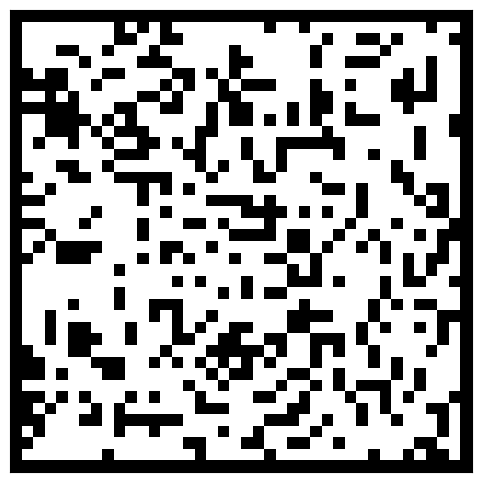

In [ ]:
# Maze generation: random obstacles but ensure path from START to GOAL exists or premade maze
RANDOM_MAZE = True

def make_maze():
    # 0-free, 1-wall
    if RANDOM_MAZE:
        while True:
            grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.int8)
            # border walls
            grid[0,:] = 1
            grid[-1,:] = 1
            grid[:,0] = 1
            grid[:,-1] = 1
            # interior random obstacles
            rand = np.random.rand(GRID_SIZE, GRID_SIZE)
            grid[(rand < OBSTACLE_PROB)] = 1
            # empty start/goal
            grid[START] = 0
            grid[GOAL] = 0
            # Ensure connectivity: run A* on this grid; if path exists accept
            path = astar(START, GOAL, grid)
            if path is not None:
                return grid
    else:
        # Feel free
        grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
        grid[0, :] = 1; grid[-1, :] = 1; grid[:, 0] = 1; grid[:, -1] = 1
        # add some internal walls
        grid[0:35, 5] = 1
        grid[5:40, 10] = 1
        grid[5, 15:40] = 1
        grid[10:35, 20] = 1
        grid[10, 20:30] = 1
        grid[15:25, 30] = 1
        path = astar(START, GOAL, grid)
        if path is not None:
            return grid

def plot_maze(grid, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(grid, origin='lower', cmap='gray_r', interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    return ax

plot_maze(make_maze())

In [ ]:
# Particle filter helpers

def init_particles_known_map(grid, num_particles):
    free_cells = list(zip(*np.where(grid==0)))
    particles = [random.choice(free_cells) for _ in range(num_particles)]
    weights = np.ones(len(particles)) / len(particles)
    return particles, weights


def predict_particles(particles, weights, action):
    new_particles = []
    for p in particles:
        if random.random() < MOTION_NOISE:
            # random move (or stay)
            if random.random() < 0.5:
                new_particles.append(p)
            else:
                move = random.choice(list(MOVES.values()))
                cand = add(p, move)
                if in_bounds(cand):
                    new_particles.append(cand)
                else:
                    new_particles.append(p)
        else:
            cand = add(p, MOVES[action])
            if in_bounds(cand):
                new_particles.append(cand)
            else:
                new_particles.append(p)
    return new_particles, weights


def expected_sensor_at(cell, grid):
    # returns a tuple of four values (N,S,W,E): 0 free, 1 obstacle,  -1 out-of-bounds
    out = []
    for d in ['N','S','W','E']:
        nb = add(cell, MOVES[d])
        if not in_bounds(nb):
            out.append(1)  # treat outside as obstacle
        else:
            out.append(int(grid[nb] == 1))
    return tuple(out)


def weight_particles_by_sensor(particles, weights, measurement, grid):
    # measurement is tuple of four ints
    new_w = np.zeros(len(weights), dtype=float)
    for i,p in enumerate(particles):
        exp = expected_sensor_at(p, grid)
        # simple likelihood: exponential of mismatches
        mismatches = sum(a!=b for a,b in zip(exp, measurement))
        if grid[p] == 1:
          new_w[i] = 0
        # likelihood: (0.5)^mismatches (tunable)
        new_w[i] = (0.1 ** mismatches)
    if new_w.sum() == 0:
        # fallback uniform
        new_w[:] = 1.0 / len(new_w)
    else:
        new_w = new_w / new_w.sum()
    return new_w


def effective_n(weights):
    return 1.0 / np.sum(np.square(weights))


def systematic_resample(particles, weights):
    N = len(weights)
    positions = (np.arange(N) + random.random()) / N
    indexes = np.zeros(N, 'i')
    cumulative_sum = np.cumsum(weights)
    i, j = 0, 0
    while i < N:
        if positions[i] < cumulative_sum[j]:
            indexes[i] = j
            i += 1
        else:
            j += 1
    new_particles = [particles[idx] for idx in indexes]
    new_weights = np.ones(N) / N
    return new_particles, new_weights

In [ ]:
# Robot class: handles both modes
class Robot:
    def __init__(self, grid, start, goal, mode='PF'):
        self.grid = grid
        self.true_pos = start
        self.start = start
        self.goal = goal
        self.mode = mode
        self.path = None
        self.est_pos = None
        # PF state
        if mode == 'PF':
            self.particles, self.weights = init_particles_known_map(grid, NUM_PARTICLES)
        else:
            self.particles, self.weights = [], []
            # mapping: robot knows its true pose always
            self.known_map = np.ones_like(grid, dtype=np.int8) * -1  # -1 unknown, 0 free, 1 occupied
            # set borders from initial perception
            self.known_map[self.true_pos] = 0

    def sense(self):
        # return measurement tuple (N,S,W,E)
        meas = expected_sensor_at(self.true_pos, self.grid)
        # allow sensor noise if desired
        return meas

    def pf_update(self, action):
        # predict
        self.particles, self.weights = predict_particles(self.particles, self.weights, action)
        # sense
        meas = self.sense()
        # weight
        self.weights = weight_particles_by_sensor(self.particles, self.weights, meas, self.grid)
        # resample if needed
        if effective_n(self.weights) < RESAMPLE_THRESHOLD * len(self.weights):
            self.particles, self.weights = systematic_resample(self.particles, self.weights)

    def mapping_update(self, action):
        # mapping mode: perfect localization
        meas = self.sense()
        # update known map for 4 neighbors
        for i,d in enumerate(['N','S','W','E']):
            nb = add(self.true_pos, MOVES[d])
            if in_bounds(nb):
                self.known_map[nb] = meas[i]
        self.known_map[self.true_pos] = 0

    def estimate_pose(self):
        if self.mode == 'PF':
            # compute weighted mean by converting discrete cells to continuous
            rs = np.array([p[0] for p in self.particles])
            cs = np.array([p[1] for p in self.particles])
            r_mean = np.average(rs, weights=self.weights)
            c_mean = np.average(cs, weights=self.weights)
            # pick nearest cell to mean
            est = (int(round(r_mean)), int(round(c_mean)))
            return est
        else:
            return self.true_pos

    def plan(self):
        # plan using map available for mode
        if self.mode == 'PF':
            # use ground truth map (particle filter mode has map known to robot)
            plan_grid = self.grid
            self.est = self.estimate_pose()
            pos = self.est
        else:
            # mapping mode: plan on the known portion of map. unknown cells treat as free (optimistic)
            plan_grid = deepcopy(self.known_map)
            plan_grid[plan_grid == -1] = 0
            pos = self.true_pos
        path = astar(pos, self.goal, plan_grid)
        self.path = path
        return path

    def step_along_path(self):
        if self.path is None or len(self.path) < 2:
            return False
        next_cell = self.path[1]
        # determine action required to move from true_pos to next_cell
        if self.mode == 'PF':
            pos = self.est
        else:
            pos = self.true_pos
        desired_r = next_cell[0] - pos[0]
        desired_c = next_cell[1] - pos[1]
        action = None
        for k,v in MOVES.items():
            if v == (desired_r,desired_c):
                action = k
                break
        moved_to_cell = add(self.true_pos, (desired_r, desired_c))
        if action is None:
            # path might be out of sync
            print('Failed action')
            return False
        # execute motion with some chance of failure
        if random.random() < MOTION_NOISE:
            # failed motion -> stay in place
            actual_move = self.true_pos
        else:
            actual_move = moved_to_cell
            # but don't move into obstacles
            if self.grid[actual_move] == 1:
                actual_move = self.true_pos
        self.true_pos = actual_move
        # update mode-specific state
        if self.mode == 'PF':
            self.pf_update(action)
        else:
            self.mapping_update(action)
        return True

In [ ]:
# Visualization

def visualize(grid, robot, show_particles=True, fig=None, ax = None, figsize=(8,8)):
    cmap = colors.ListedColormap(['white','black'])
    if fig == None and ax == None:
        fig, ax = plt.subplots(figsize=figsize)
    ax.clear()
    ax.set_xticks(np.arange(-0.5, GRID_SIZE, 1))
    ax.set_yticks(np.arange(-0.5, GRID_SIZE, 1))
    ax.grid(True, linewidth=0.3)
    ax.imshow(grid, origin='upper', cmap=cmap)
    # draw known map if mapping mode
    if robot.mode == 'MAP':
        km = robot.known_map
        # overlay unknown as light gray
        unknown_mask = (km == -1)
        ax.imshow(unknown_mask.astype(float), origin='upper', cmap=colors.ListedColormap(['none','lightgray']), alpha=0.6)
    # particles
    if show_particles and robot.mode == 'PF' and len(robot.particles) > 0:
        rs = [p[0] for p in robot.particles]
        cs = [p[1] for p in robot.particles]
        ax.scatter(cs, rs, s=8, alpha=0.4, label='particles')
    # robot true pos
    rp = robot.true_pos
    ax.add_patch(Rectangle((rp[1]-0.5, rp[0]-0.5),1,1, fill=True, edgecolor='red', linewidth=2, label='robot'))
    # estimated pose
    est = robot.estimate_pose()
    ax.add_patch(Rectangle((est[1]-0.5, est[0]-0.5),1,1, fill=False, edgecolor='cyan', linewidth=2, label='estimate'))
    # start and goal
    ax.add_patch(Rectangle((START[1]-0.5, START[0]-0.5),1,1, fill=True, edgecolor='green', facecolor='green', alpha=0.6))
    ax.add_patch(Rectangle((GOAL[1]-0.5, GOAL[0]-0.5),1,1, fill=True, edgecolor='gold', facecolor='gold', alpha=0.6))
    # path
    if robot.path is not None:
        path = robot.path
        ys = [p[0] for p in path]
        xs = [p[1] for p in path]
        ax.plot(xs, ys, '-', linewidth=2, alpha=0.9)
    ax.set_xlim(-0.5, GRID_SIZE-0.5)
    ax.set_ylim(GRID_SIZE-0.5, -0.5)
    ax.set_title(f"Mode: {robot.mode} | True: {robot.true_pos} | Est: {est}")
    ax.legend(handles=ax.get_legend_handles_labels()[0])
    # plt.show()
    display.display(fig)
    display.clear_output(wait=True)

In [ ]:
# Run a simulation

def run_simulation(mode='PF', show_every=1, visualize_final=True):
    grid = make_maze()
    robot = Robot(grid, START, GOAL, mode=mode)
    fig, ax = plt.subplots(figsize=(8,8))
    # initial sense
    if mode == 'PF':
        # initial weight update with initial sensing
        robot.pf_update('N')  # do an initial predict+update with dummy action
    else:
        robot.mapping_update(None)
    step = 0
    success = False
    while step < MAX_STEPS:
        # plan
        path = robot.plan()
        if path is None:
            print("No path found from estimate to goal")
        if len(path) >= 2 and path[1] == robot.true_pos:
            # edge case; recalc
            robot.plan()
        # if estimated or true at goal
        if robot.estimate_pose() == GOAL or robot.true_pos == GOAL:
            success = True
            print(f"Reached goal at step {step}")
            break
        moved = robot.step_along_path()
        if not moved:
            # try replanning
            robot.plan()
        step += 1
        if step % show_every == 0:
            visualize(grid, robot, show_particles=True, fig=fig, ax=ax)
    if visualize_final:
        visualize(grid, robot, show_particles=True, fig=fig, ax=ax)
    time.sleep(0.1)
    return robot, grid, success

No path found from estimate to goal


TypeError: object of type 'NoneType' has no len()

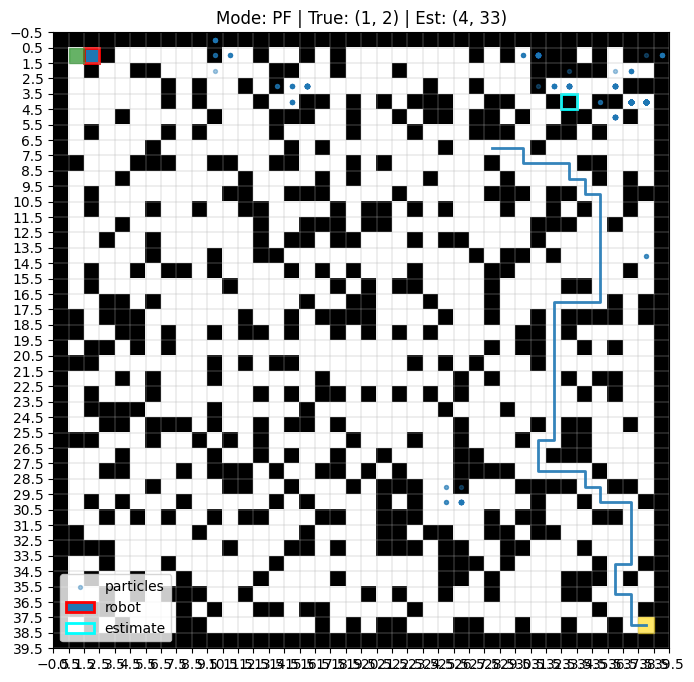

In [ ]:
# Example runs
if __name__ == '__main__':
    # Choose mode: 'PF' or 'MAP'
    print("Running particle-filter localization mode example...")
    MODE = 'PF'
    r_pf, g_pf, s_pf = run_simulation(mode=MODE, show_every=1)

    # print("\nRunning mapping (perfect localization) mode example...")
    # MODE = 'MAP'
    # r_map, g_map, s_map = run_simulation(mode=MODE, show_every=1)